<a href="https://colab.research.google.com/github/farelagustin/2026_kecerdasan_buatan/blob/main/Jobsheet_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Moh Farel Agustin
- **NIM:** 4.33.25.0.14
- **Kelas:** TI-1A

## Menentukan Pertanyaan Bisnis

- Performa total penyewaan sepeda jika dilihat berdasarkan musim (season)? Musim apa yang mencatatkan rental tertinggi?

- Bagaimana pola penyewaan sepeda per jam (hr) pada hari kerja (workingday) dibandingkan dengan hari libur/akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [4]:
day_df = pd.read_csv("https://raw.githubusercontent.com/farelagustin/LatihanEDA/refs/heads/main/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
hour_df = pd.read_csv("https://raw.githubusercontent.com/farelagustin/LatihanEDA/refs/heads/main/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

In [7]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [9]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [10]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [11]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


### Cleaning Data

In [12]:
day_df.duplicated().sum()

np.int64(0)

In [14]:
hour_df.duplicated().sum()

np.int64(0)

np.int64(0)

## Exploratory Data Analysis (EDA)

# Eksplorasi Pertanyaan 1 (Pengaruh Musim)
Mari kita kelompokkan total penyewaan (cnt), pelanggan kasual (casual), dan pelanggan terdaftar (registered) berdasarkan musim (season).

In [20]:
# Mapping angka musim menjadi nama agar mudah dibaca
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_name'] = day_df['season'].map(season_mapping)

# Membuat pivot/summary
season_summary = day_df.groupby('season_name')[['casual', 'registered', 'cnt']].mean().sort_values(by='cnt', ascending=False)
print(season_summary)

                  casual   registered          cnt
season_name                                       
Fall         1202.611702  4441.691489  5644.303191
Summer       1106.097826  3886.233696  4992.331522
Winter        729.112360  3999.050562  4728.162921
Spring        334.928177  2269.204420  2604.132597


# Eksplorasi Pertanyaan 2 (Pola Jam pada Hari Kerja vs Hari Libur)
Mari kita lihat rata-rata penyewaan per jam berdasarkan status hari kerja (workingday).

In [21]:
hourly_summary = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().unstack(level=0)
print(hourly_summary)

workingday           0           1
hr                                
0            90.800000   36.786290
1            69.508696   16.552632
2            53.171053    8.683778
3            25.775330    4.942553
4             8.264317    5.429787
5             8.689189   24.913131
6            18.742358  102.500000
7            43.406926  290.612903
8           105.653680  477.006048
9           171.623377  241.518145
10          255.909091  135.366935
11          315.316017  158.229839
12          366.259740  200.820926
13          372.731602  198.429719
14          364.645022  183.572289
15          358.813853  201.331325
16          352.727273  293.122244
17          323.549784  525.290581
18          281.056522  492.226908
19          231.673913  348.401606
20          174.739130  249.718876
21          142.060870  186.287149
22          116.060870  138.389558
23           85.930435   88.708835


## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Penyewaan Berdasarkan Musim

/tmp/ipykernel_40227/3046600396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season_name', y='cnt', data=day_df, estimator='mean', errorbar=None, palette='Blues_r')


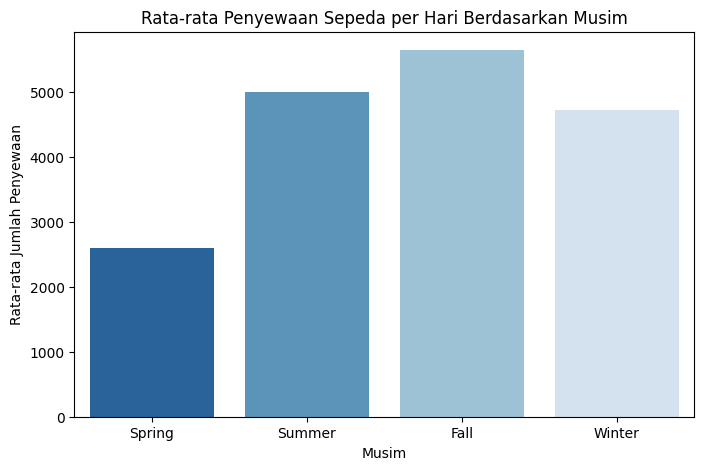

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x='season_name', y='cnt', data=day_df, estimator='mean', errorbar=None, palette='Blues_r')
plt.title('Rata-rata Penyewaan Sepeda per Hari Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

### Pertanyaan 2: Pola Penyewaan per Jam (Hari Kerja vs Hari Libur)

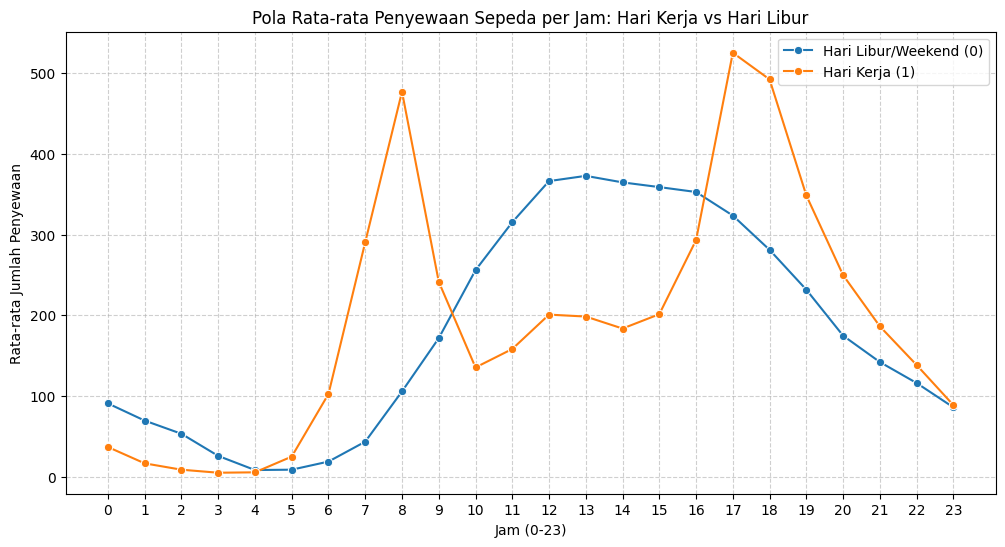

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', hue='workingday', data=hour_df, estimator='mean', errorbar=None, marker='o')
plt.title('Pola Rata-rata Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(range(0, 24))
plt.legend(['Hari Libur/Weekend (0)', 'Hari Kerja (1)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Conclusion

- Conclution pertanyaan 1: Strategi bisnis atau promo sebaiknya dimaksimalkan pada musim Fall (Gugur) karena mencatat volume rental tertinggi, dan berikan stimulus khusus pada musim Spring (Semi) karena performanya paling rendah.


- Conclution pertanyaan 2: Pola peminjaman sepeda pada hari kerja sangat dipengaruhi oleh jam komuter (berangkat & pulang kerja), sedangkan pada hari libur lebih didominasi oleh aktivitas kasual/wisata di siang hingga sore hari.